In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Quantitative Momentum — Signal Research

**Universe:** S&P 500 constituents (point-in-time, from CRSP). Loaded from `sp500_constituents.parquet`.
**Signal:**
1. **12-1 month momentum**: log-return over 252d minus most recent 21d
2. **FIP quality filter**: sign(12m return) × (%neg_days − %pos_days) over the same 252d window. More negative FIP = smoother uptrend = better.

**Selection:** Top 10% by momentum, then top 50% of those by FIP (lowest = smoothest).
**Rebalance:** Quarterly — last trading day of Feb, May, Aug, Nov (Gray & Vogel convention).
**Weighting:** Both **equal-weight (EW)** and **value-weight (VW)** computed; winner by Sharpe is canonical.
**Direction:** Long-only.

**Academic backing:** Gray & Vogel (2016), *Quantitative Momentum: A Practitioner's Guide*.

**Adaptations from book's original:**
- **S&P 500 universe instead of full CRSP cross-section** — practical for real-life trading (liquid, ~500 names instead of ~4000+)
- **No SIC exclusions** — S&P 500 already curated, financials and utilities (JPM, V, NEE, SO) are valid momentum candidates
- **No size screen** — S&P 500 stocks are all well above any size threshold
- **No fees baked in** — standardized 9-col trades CSV; fees applied at PM layer

**Sizing & implementation** → see `quantitative_momentum_Implementation.ipynb`

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
CONSTITUENTS_PATH = r"C:\Users\danie\Desktop\algo_trading\data\wrds\05_sp500_crsp.parquet"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "Quantitative Momentum"
SAVE_NAME        = "quantitative_momentum"

# Strategy parameters (from Gray & Vogel 2016)
TOP_DECILE_PCT    = 0.10   # top 10% by momentum
FIP_KEEP_FRAC     = 0.50   # top 50% of top decile by FIP
REBALANCE_MONTHS  = [2, 5, 8, 11]   # end of Feb, May, Aug, Nov

# Signal windows (in trading days)
LOOKBACK_DAYS     = 252    # ~12 months
SKIP_DAYS         = 21     # ~1 month to skip
MIN_DAYS          = 180    # minimum valid days in window

# CRSP DlyCap is in thousands of dollars
DLYCAP_MULT = 1_000

# Minimum portfolio size at each rebalance
MIN_NAMES_PER_PORTFOLIO = 5

# Date filter — restrict to modern era for apples-to-apples comparison with other strategies.
# The CRSP file goes back to 1928 but the rest of Portfolio B runs 2006-2026 (Alpaca era).
# Set to None to use full history.
MIN_DATE = "2006-01-01"   # matches IBS / GTAA baseline
MAX_DATE = None           # None = use up to last available date

## 2. Load S&P 500 Constituents

> **⚠️ DATA SOURCE — REVIEW LATER**
>
> This notebook uses **CRSP's pre-bundled SP500 Constituents file**, originally downloaded as `n1rzhu7y7nz0bs7n_csv.zip` from `WRDS_DATASETS/CRSP [done]/3. Index (V2 CIZ)/7. SP500 Constituents/`. CRSP packages this as a convenience product: it combines membership history + daily prices/returns/caps in one file (~3M rows).
>
> **This is NOT the same as `05_na_sp_index_constituents.parquet`** in the new WRDS pipeline (`shared/wrds_data.py`). That file is just the Compustat membership table (`idxcst_his`, ~24K rows, no prices). To replicate this notebook through the new pipeline, you would need to:
>   1. Download dataset **#3 NA Security Daily** (`comp_na_daily_all.secd`, ~150M rows — manual MONSTER download, currently pending per memory)
>   2. Filter #3 to S&P 500 stocks via the gvkey/date ranges in #5
>
> **Migration TODO when #3 is downloaded:**
> - Build a `load_sp500_constituents()` helper in `shared/wrds_data.py` that joins #3 + #5
> - Re-run this notebook against the new source
> - Validate that results match (CRSP and Compustat should agree on SP500 prices to the penny)
> - Then deprecate this CRSP zip path

The cell below loads the parquet if it exists at `algo_trading/data/wrds/sp500_constituents.parquet`. If not, it builds the parquet once from the original CRSP zip.

In [4]:
# =============================================================================
# DATA LOADER — uses CRSP zip → parquet (REVIEW NOTE above)
# =============================================================================
import zipfile
from pathlib import Path

PARQUET_PATH = Path(r"C:\Users\danie\Desktop\algo_trading\data\wrds\05_sp500_crsp.parquet")
CRSP_ZIP_PATH = Path(r"C:\Users\danie\Desktop\AlgoTrading\WRDS_DATASETS\CRSP [done]\3. Index (V2 CIZ)\7. SP500 Constituents\n1rzhu7y7nz0bs7n_csv.zip")


# Cols we actually use downstream (lighter parquet, faster load)
KEEP_COLS_RAW = ["DlyCalDt", "PERMNO", "Ticker", "DlyClose", "DlyRet", "DlyCap"]

if not PARQUET_PATH.exists():
    print(f"Parquet not found at {PARQUET_PATH}")
    print(f"Building once from CRSP zip: {CRSP_ZIP_PATH}")
    if not CRSP_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"Neither parquet nor source zip found.\n"
            f"Parquet:  {PARQUET_PATH}\n"
            f"Zip:      {CRSP_ZIP_PATH}\n"
            f"Re-download from WRDS or update the paths above."
        )

    # Build parquet from CRSP zip in chunks (memory-safe — file is large)
    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    chunks = []
    t0 = time.time()
    with zipfile.ZipFile(CRSP_ZIP_PATH) as z:
        csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
        with z.open(csv_name) as f:
            reader = pd.read_csv(f, chunksize=500_000, low_memory=False,
                                  parse_dates=["DlyCalDt"])
            for i, chunk in enumerate(reader):
                chunks.append(chunk[[c for c in KEEP_COLS_RAW if c in chunk.columns]])
                print(f"  Chunk {i+1}: {len(chunk):,} rows ({time.time()-t0:.1f}s elapsed)")
    raw = pd.concat(chunks, ignore_index=True)
    raw.to_parquet(PARQUET_PATH, index=False)
    print(f"  Built parquet: {len(raw):,} rows, saved to {PARQUET_PATH}")
    del raw, chunks
    gc.collect()

print("Loading constituents parquet...")
t0 = time.time()
stocks = pd.read_parquet(PARQUET_PATH)
print(f"  {len(stocks):,} rows in {time.time()-t0:.1f}s")
print(f"  Columns: {list(stocks.columns)}")

# --- cleaning + downcast (replaces the old block) ---
stocks.columns = stocks.columns.str.lower()
stocks["dlycaldt"] = pd.to_datetime(stocks["dlycaldt"])
stocks["mktcap"] = (stocks["dlycap"] * DLYCAP_MULT).astype("float32")

stocks = stocks.astype({
    "permno": "int32",
    "ticker": "category",
    "dlyret": "float32",
    "dlyclose": "float32",
})

keep_cols = ["dlycaldt", "permno", "ticker", "dlyret", "dlyclose", "mktcap"]
stocks = stocks[[c for c in keep_cols if c in stocks.columns]]
stocks = stocks.dropna(subset=["dlyret", "mktcap"])
stocks = stocks.sort_values(["permno", "dlycaldt"], ignore_index=True)
gc.collect()

print(f"\n  After cleaning: {len(stocks):,} rows, {stocks['permno'].nunique():,} unique stocks")
print(f"  Memory: {stocks.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Date range: {stocks['dlycaldt'].min().date()} → {stocks['dlycaldt'].max().date()}")

# --- date filter (keep as-is) ---
if MIN_DATE is not None:
    stocks = stocks[stocks["dlycaldt"] >= pd.Timestamp(MIN_DATE)].reset_index(drop=True)
if MAX_DATE is not None:
    stocks = stocks[stocks["dlycaldt"] <= pd.Timestamp(MAX_DATE)].reset_index(drop=True)
gc.collect()

print(f"\n  After date filter [{MIN_DATE} → {MAX_DATE or 'end'}]: {len(stocks):,} rows, {stocks['permno'].nunique():,} unique stocks")
print(f"  Date range: {stocks['dlycaldt'].min().date()} → {stocks['dlycaldt'].max().date()}")

Loading constituents parquet...
  9,404,934 rows in 11.1s
  Columns: ['INDNO', 'MbrStartDt', 'MbrEndDt', 'PERMNO', 'HdrCUSIP', 'PERMCO', 'SICCD', 'CUSIP', 'Ticker', 'ShareType', 'SecurityType', 'SecuritySubType', 'USIncFlg', 'IssuerType', 'PrimaryExch', 'ConditionalType', 'TradingStatusFlg', 'DlyCalDt', 'DlyPrc', 'DlyPrcFlg', 'DlyCap', 'DlyCapFlg', 'DlyRet', 'DlyRetx', 'DlyRetMissFlg', 'DlyRetDurFlg', 'DlyOrdDivAmt', 'DlyNonOrdDivAmt', 'DlyFacPrc', 'DlyDistRetFlg', 'DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh', 'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd', 'DlyMMCnt', 'DlyCumFacPr', 'DlyCumFacShr', 'ShrOut']

  After cleaning: 9,401,244 rows, 1,937 unique stocks
  Memory: 244.6 MB
  Date range: 1928-08-24 → 2025-12-31

  After date filter [2006-01-01 → end]: 2,526,977 rows, 941 unique stocks
  Date range: 2006-01-03 → 2025-12-31


## 3. Compute Signals

12-1 momentum and FIP, vectorized per PERMNO.

In [5]:
print("Computing signals (vectorized)...")
t0 = time.time()

# Log return for compounding
stocks["log_ret"] = np.log1p(stocks["dlyret"])

# Day flags for FIP
stocks["pos_day"] = (stocks["dlyret"] > 0).astype("int8")
stocks["neg_day"] = (stocks["dlyret"] < 0).astype("int8")

grp = stocks.groupby("permno", sort=False)

# Full 252-day cumulative log return
stocks["logret_252"] = grp["log_ret"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
# Recent 21-day cumulative log return (to subtract for 12-1 skip)
stocks["logret_21"] = grp["log_ret"].transform(
    lambda x: x.rolling(SKIP_DAYS, min_periods=SKIP_DAYS).sum()
)
# Momentum (12-1) = 12m return minus most recent month
stocks["mom_12_1"] = np.expm1(stocks["logret_252"] - stocks["logret_21"])

# FIP components over full 252 days
stocks["pos_252"] = grp["pos_day"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
stocks["neg_252"] = grp["neg_day"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
stocks["cnt_252"] = grp["log_ret"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).count()
)

stocks["pct_pos"] = stocks["pos_252"] / stocks["cnt_252"]
stocks["pct_neg"] = stocks["neg_252"] / stocks["cnt_252"]
stocks["ret_12m"] = np.expm1(stocks["logret_252"])

# FIP = sign(12m return) * (%negative - %positive)
# More negative = smoother upward path = better
stocks["fip"] = np.sign(stocks["ret_12m"]) * (stocks["pct_neg"] - stocks["pct_pos"])

# Drop intermediate cols to save memory
stocks = stocks.drop(columns=["logret_252", "logret_21", "pos_252", "neg_252",
                                "cnt_252", "pct_pos", "pct_neg", "ret_12m",
                                "log_ret", "pos_day", "neg_day"])
gc.collect()

print(f"  Signals computed in {time.time()-t0:.1f}s")
print(f"  Rows with valid momentum: {stocks['mom_12_1'].notna().sum():,}")
print(f"  Rows with valid FIP:      {stocks['fip'].notna().sum():,}")

Computing signals (vectorized)...
  Signals computed in 2.5s
  Rows with valid momentum: 2,363,379
  Rows with valid FIP:      2,363,379


## 4. Rebalance Dates

In [6]:
# Last trading day of Feb, May, Aug, Nov
all_dates = stocks[["dlycaldt"]].drop_duplicates().sort_values("dlycaldt").reset_index(drop=True)
all_dates["month"] = all_dates["dlycaldt"].dt.month
all_dates["year"]  = all_dates["dlycaldt"].dt.year

rebal_dates = (
    all_dates[all_dates["month"].isin(REBALANCE_MONTHS)]
    .groupby(["year", "month"])["dlycaldt"]
    .max()
    .sort_values()
    .values
)
rebal_list = [pd.Timestamp(d) for d in rebal_dates]
print(f"Rebalance dates: {len(rebal_list)}")
print(f"  First: {rebal_list[0].date()}")
print(f"  Last:  {rebal_list[-1].date()}")

Rebalance dates: 80
  First: 2006-02-28
  Last:  2025-11-28


## 5. Build 9-Col Trades CSV

For each rebalance date, select QMom stocks. Each name held until next rebalance becomes one trade in the standardized 9-col format. Both EW and VW variants are computed.

In [7]:
print("Pre-indexing by date...")
t0 = time.time()

# Snapshot data: only rows with both momentum and FIP valid
snap_data = stocks.dropna(subset=["mom_12_1", "fip"])
snap_by_date = {
    date: grp[["permno", "ticker", "dlyclose", "mom_12_1", "fip", "mktcap"]].reset_index(drop=True)
    for date, grp in snap_data.groupby("dlycaldt")
}

# Price data: for finding exit prices on rebal dates, indexed by (date, permno)
price_lookup = stocks.set_index(["dlycaldt", "permno"])["dlyclose"]

print(f"  Pre-indexed in {time.time()-t0:.1f}s")
print(f"  Snap dates available: {len(snap_by_date):,}")

Pre-indexing by date...
  Pre-indexed in 4.5s
  Snap dates available: 4,852


In [8]:
print("Building trades for both EW and VW variants...")
t0 = time.time()

def build_trades(rebal_list, snap_by_date, price_lookup):
    """
    Walk through rebalance dates. At each rebal date, select QMom names,
    look up exit price at next rebal date, emit one row per name per period
    in the standardized 9-col schema. Returns trades_ew, trades_vw.

    EW and VW differ only in implicit weighting — the trade list is the
    same set of (permno, period). Weight info is in the 'mktcap' column
    so the Implementation notebook can compute either weighting.
    """
    trades = []
    skipped = 0

    for i in range(len(rebal_list) - 1):
        rdate = rebal_list[i]
        ndate = rebal_list[i + 1]

        snap = snap_by_date.get(rdate)
        if snap is None or len(snap) < 20:
            skipped += 1
            continue

        n     = len(snap)
        n_top = max(int(n * TOP_DECILE_PCT), 10)
        n_qm  = max(int(n_top * FIP_KEEP_FRAC), MIN_NAMES_PER_PORTFOLIO)

        # Top 10% by momentum, then top 50% of those by FIP (ascending = best)
        top_mom = snap.nlargest(n_top, "mom_12_1")
        top_qm  = top_mom.nsmallest(n_qm, "fip")

        # For each selected name, build a trade
        for _, row in top_qm.iterrows():
            permno = row["permno"]
            entry_price = row["dlyclose"]
            entry_mktcap = row["mktcap"]
            ticker = row["ticker"] if pd.notna(row["ticker"]) else f"PERMNO_{int(permno)}"

            # Look up exit price on next rebalance date
            try:
                exit_price = price_lookup.loc[(ndate, permno)]
            except KeyError:
                # Stock dropped from index between rebals; use last available price
                stock_prices = stocks[(stocks["permno"] == permno) &
                                       (stocks["dlycaldt"] > rdate) &
                                       (stocks["dlycaldt"] <= ndate)]
                if stock_prices.empty:
                    continue
                exit_price = stock_prices["dlyclose"].iloc[-1]
                actual_exit = stock_prices["dlycaldt"].iloc[-1]
            else:
                actual_exit = ndate

            if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
                continue

            pct_return_gross = (exit_price - entry_price) / entry_price

            trades.append({
                "entry_time":       rdate,
                "exit_time":        actual_exit,
                "direction":        "long",
                "instrument":       str(ticker),
                "entry_price":      round(float(entry_price), 4),
                "exit_price":       round(float(exit_price), 4),
                "pct_return_gross": round(float(pct_return_gross), 6),
                "exit_reason":      "rebalance",
                "stop_price":       np.nan,
                # Extra cols for VW variant — not in standard schema, dropped on save
                "permno":           int(permno),
                "entry_mktcap":     float(entry_mktcap),
            })

    print(f"  Built {len(trades):,} trades, skipped {skipped} rebal periods")
    return pd.DataFrame(trades)

trades_all = build_trades(rebal_list, snap_by_date, price_lookup)
trades_all["entry_time"] = pd.to_datetime(trades_all["entry_time"])
trades_all["exit_time"]  = pd.to_datetime(trades_all["exit_time"])
print(f"  Done in {time.time()-t0:.1f}s")
print(f"\n  Avg trades per rebalance: {len(trades_all) / len(rebal_list):.1f}")
print(f"  Avg hold days: {(trades_all['exit_time'] - trades_all['entry_time']).dt.days.mean():.1f}")
print(f"  Win rate (gross): {(trades_all['pct_return_gross'] > 0).mean()*100:.1f}%")
print(f"  Avg gross return: {trades_all['pct_return_gross'].mean()*100:.3f}%")

Building trades for both EW and VW variants...
  Built 1,813 trades, skipped 3 rebal periods
  Done in 1.6s

  Avg trades per rebalance: 22.7
  Avg hold days: 90.7
  Win rate (gross): 54.2%
  Avg gross return: 1.040%


## 6. Build Daily Equity for Both Weighting Variants

EW: each name in the period gets 1/N weight. VW: weight by entry mktcap.

In [9]:
def build_portfolio_daily_equity(trades, stocks, weighting="ew", starting_capital=STARTING_CAPITAL):
    """
    For each rebalance period, compute daily portfolio return as weighted average
    of the held names' daily returns. Compound across periods.

    weighting: 'ew' = equal-weight, 'vw' = value-weighted by entry mktcap.
    """
    trades = trades.copy()
    trades["period_start"] = trades["entry_time"]

    # Daily returns lookup: (date, permno) -> dlyret
    daily_ret_lookup = stocks.set_index(["dlycaldt", "permno"])["dlyret"]

    # Build full daily index from first entry to last exit
    all_idx = pd.DatetimeIndex(sorted(set(stocks["dlycaldt"])))
    all_idx = all_idx[(all_idx >= trades["entry_time"].min()) & (all_idx <= trades["exit_time"].max())]

    portfolio_daily_ret = pd.Series(0.0, index=all_idx)

    # Group trades by period
    for period_start, period_trades in trades.groupby("period_start"):
        if period_trades.empty:
            continue
        period_end = period_trades["exit_time"].max()
        period_dates = all_idx[(all_idx > period_start) & (all_idx <= period_end)]
        if len(period_dates) == 0:
            continue

        # Weights
        if weighting == "ew":
            weights = pd.Series(1.0 / len(period_trades), index=period_trades["permno"].values)
        else:  # vw
            mktcaps = period_trades.set_index("permno")["entry_mktcap"]
            weights = mktcaps / mktcaps.sum()

        # Daily portfolio return for this period
        for d in period_dates:
            day_ret = 0.0
            for permno, w in weights.items():
                try:
                    r = daily_ret_lookup.loc[(d, permno)]
                    if pd.notna(r):
                        day_ret += w * r
                except KeyError:
                    pass  # name dropped on this date; treated as 0 return
            portfolio_daily_ret.loc[d] = day_ret

    # Compound to equity curve
    eq = starting_capital * (1 + portfolio_daily_ret).cumprod()
    return eq, portfolio_daily_ret

print("Building EW daily equity...")
t0 = time.time()
eq_ew, ret_ew = build_portfolio_daily_equity(trades_all, stocks, weighting="ew")
print(f"  Done in {time.time()-t0:.1f}s")

print("Building VW daily equity...")
t0 = time.time()
eq_vw, ret_vw = build_portfolio_daily_equity(trades_all, stocks, weighting="vw")
print(f"  Done in {time.time()-t0:.1f}s")

Building EW daily equity...
  Done in 11.7s
Building VW daily equity...
  Done in 11.9s


In [10]:
def stats_from_eq(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

s_ew = stats_from_eq(eq_ew, ret_ew)
s_vw = stats_from_eq(eq_vw, ret_vw)

# SPY benchmark over same window using sprtrn if available, else compute from constituent agg
# Try to use a SPY-style benchmark from the constituents data (sp500_avg_ret per day)
spy_ret = stocks.groupby("dlycaldt")["dlyret"].mean()
spy_ret = spy_ret.reindex(eq_ew.index).fillna(0)
eq_spy = STARTING_CAPITAL * (1 + spy_ret).cumprod()
s_spy = stats_from_eq(eq_spy, spy_ret)

print(f"\n{'Variant':<25} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 65)
print(f"{'S&P 500 avg (proxy)':<25} {s_spy['total_return']:>10,.1f} {s_spy['cagr']:>8.2f} {s_spy['sharpe']:>8.2f} {s_spy['max_dd']:>8.1f}")
print(f"{'QMom equal-weight':<25} {s_ew['total_return']:>10,.1f} {s_ew['cagr']:>8.2f} {s_ew['sharpe']:>8.2f} {s_ew['max_dd']:>8.1f}")
print(f"{'QMom value-weight':<25} {s_vw['total_return']:>10,.1f} {s_vw['cagr']:>8.2f} {s_vw['sharpe']:>8.2f} {s_vw['max_dd']:>8.1f}")


Variant                      TotRet%    CAGR%   Sharpe   MaxDD%
-----------------------------------------------------------------
S&P 500 avg (proxy)            555.3    10.40     0.56    -59.0
QMom equal-weight              288.0     7.40     0.42    -58.2
QMom value-weight              876.1    12.74     0.61    -50.1


## 7. Significance Tests

In [11]:
print("=" * 70)
print("SIGNIFICANCE — Equal-weight")
print("=" * 70)
sig_ew = pd.DataFrame({"net_pnl": ret_ew.values, "equity_before": 1.0,
                        "position": "long", "direction": "long"})
report_ew = full_significance_report(sig_ew, strategy_name="QMom EW")
print_significance_report(report_ew)

print("\n" + "=" * 70)
print("SIGNIFICANCE — Value-weight")
print("=" * 70)
sig_vw = pd.DataFrame({"net_pnl": ret_vw.values, "equity_before": 1.0,
                        "position": "long", "direction": "long"})
report_vw = full_significance_report(sig_vw, strategy_name="QMom VW")
print_significance_report(report_vw)

SIGNIFICANCE — Equal-weight

STATISTICAL SIGNIFICANCE — QMom EW

1. t-test (returns > 0)
   Mean return:  0.0393% per trade
   t-statistic:  1.839
   p-value:      0.032987
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.4223
   95% CI:            [-0.0355, 0.8792]
   % below zero:      3.51%
   Significant:       NO

3. Permutation test (random signs)
   Observed Sharpe:   0.4223
   p-value:           0.0334
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (moderate) (2/3 tests pass)

SIGNIFICANCE — Value-weight

STATISTICAL SIGNIFICANCE — QMom VW

1. t-test (returns > 0)
   Mean return:  0.0599% per trade
   t-statistic:  2.6543
   p-value:      0.003986
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.6096
   95% CI:            [0.1557, 1.071]
   % below zero:      0.43%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.6096
 

## 8. Equity Plot

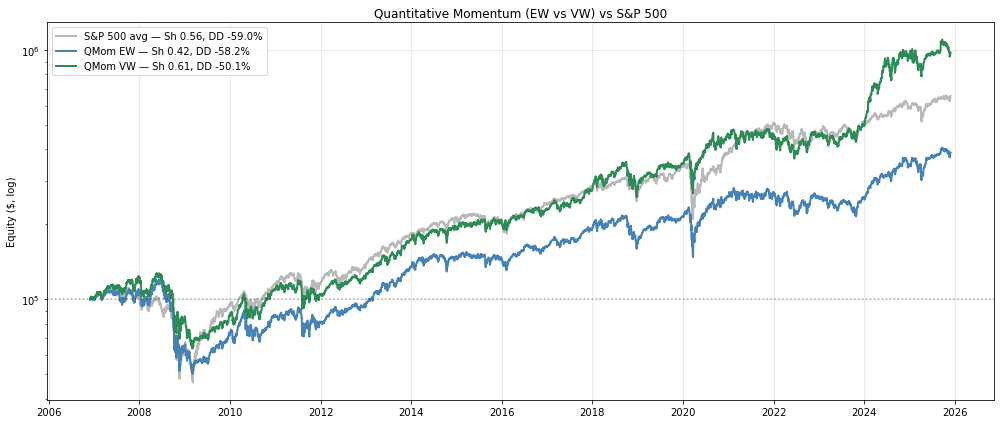

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq_spy.index.to_numpy(), eq_spy.values,
        label=f"S&P 500 avg — Sh {s_spy['sharpe']}, DD {s_spy['max_dd']}%",
        color="gray", alpha=0.55, linewidth=2)
ax.plot(eq_ew.index.to_numpy(), eq_ew.values,
        label=f"QMom EW — Sh {s_ew['sharpe']}, DD {s_ew['max_dd']}%",
        color="steelblue", linewidth=2)
ax.plot(eq_vw.index.to_numpy(), eq_vw.values,
        label=f"QMom VW — Sh {s_vw['sharpe']}, DD {s_vw['max_dd']}%",
        color="seagreen", linewidth=2)
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_title("Quantitative Momentum (EW vs VW) vs S&P 500")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($, log)")
plt.tight_layout(); plt.show()

## 9. Per-Period Diagnostics

In [13]:
# Number of names selected per rebalance period
period_summary = trades_all.groupby("entry_time").agg(
    n_names=("permno", "nunique"),
    avg_mom=("pct_return_gross", "mean"),
    win_rate=("pct_return_gross", lambda x: (x > 0).mean()),
).reset_index()

print(f"Avg names per rebalance: {period_summary['n_names'].mean():.1f}")
print(f"Min: {period_summary['n_names'].min()}, Max: {period_summary['n_names'].max()}")
print(f"Avg per-period win rate: {period_summary['win_rate'].mean()*100:.1f}%")

# Show last 5 rebalance periods
print(f"\nLast 5 rebalance periods:")
print(period_summary.tail(5).to_string(index=False))

Avg names per rebalance: 23.9
Min: 23, Max: 24
Avg per-period win rate: 54.2%

Last 5 rebalance periods:
entry_time  n_names   avg_mom  win_rate
2024-08-30       24  0.062149  0.750000
2024-11-29       24 -0.034195  0.458333
2025-02-28       24  0.016473  0.458333
2025-05-30       24  0.039262  0.625000
2025-08-29       24 -0.023153  0.500000


## 10. Variant Selection & Save

In [14]:
# Pick winner by Sharpe
sharpe_lift_vw = s_vw["sharpe"] - s_ew["sharpe"]
if sharpe_lift_vw >= 0:
    winner = "vw"
    winner_eq = eq_vw
    winner_ret = ret_vw
    winner_stats = s_vw
    winner_report = report_vw
    print(f"Winner: VALUE-WEIGHT (Sharpe {s_vw['sharpe']} vs EW {s_ew['sharpe']}, lift {sharpe_lift_vw:+.2f})")
else:
    winner = "ew"
    winner_eq = eq_ew
    winner_ret = ret_ew
    winner_stats = s_ew
    winner_report = report_ew
    print(f"Winner: EQUAL-WEIGHT (Sharpe {s_ew['sharpe']} vs VW {s_vw['sharpe']}, lift {-sharpe_lift_vw:+.2f})")

Winner: VALUE-WEIGHT (Sharpe 0.61 vs EW 0.42, lift +0.19)


In [15]:
import json

os.makedirs("results", exist_ok=True)

# Save standardized 9-col trades CSV (drop helper cols permno + entry_mktcap)
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
trades_all[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(trades_all):,} trades → results/{SAVE_NAME}_trades.csv")

# Save extended trades CSV (with permno + entry_mktcap) for Implementation notebook
ext_cols = std_cols + ["permno", "entry_mktcap"]
trades_all[ext_cols].to_csv(f"results/{SAVE_NAME}_trades_extended.csv", index=False)
print(f"Saved extended trades (with weights) → results/{SAVE_NAME}_trades_extended.csv")

# Save daily equity for both variants
eq_ew.to_csv(f"results/{SAVE_NAME}_daily_equity_ew.csv")
eq_vw.to_csv(f"results/{SAVE_NAME}_daily_equity_vw.csv")
eq_spy.to_csv(f"results/{SAVE_NAME}_daily_equity_spybench.csv")

summary = {
    "strategy": STRATEGY_NAME,
    "universe": "S&P 500 constituents (point-in-time, CRSP)",
    "portfolio": "long_term",
    "period": f"{trades_all['entry_time'].min().date()} → {trades_all['exit_time'].max().date()}",
    "params": {
        "top_decile_pct": TOP_DECILE_PCT,
        "fip_keep_frac":  FIP_KEEP_FRAC,
        "rebalance_months": REBALANCE_MONTHS,
        "lookback_days": LOOKBACK_DAYS,
        "skip_days": SKIP_DAYS,
    },
    "param_source": "Gray & Vogel (2016) Quantitative Momentum",
    "winner": winner,
    "n_trades": len(trades_all),
    "n_rebalances": len(rebal_list),
    "avg_names_per_rebalance": float(period_summary["n_names"].mean()),
    "variants": {
        "equal_weight":  {"stats": s_ew,
                           "significance": {"sharpe": report_ew["bootstrap"]["observed_sharpe"],
                                             "verdict": report_ew["verdict"],
                                             "tests_passed": report_ew["tests_passed"]}},
        "value_weight":  {"stats": s_vw,
                           "significance": {"sharpe": report_vw["bootstrap"]["observed_sharpe"],
                                             "verdict": report_vw["verdict"],
                                             "tests_passed": report_vw["tests_passed"]}},
    },
    "spy_benchmark": s_spy,
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary → results/{SAVE_NAME}_summary.json")
print(f"\nNext: run quantitative_momentum_Implementation.ipynb")

Saved 1,813 trades → results/quantitative_momentum_trades.csv
Saved extended trades (with weights) → results/quantitative_momentum_trades_extended.csv
Saved summary → results/quantitative_momentum_summary.json

Next: run quantitative_momentum_Implementation.ipynb


In [16]:
# ============================================================
# Diagnostic: Top-5 EW (highest-conviction momentum, no size bias)
# ============================================================
# Builds a 3rd variant: keep only top 5 by momentum from each rebalance,
# equal-weighted. If Sharpe ≈ VW (0.64), the signal is real — VW just encodes
# concentration. If Sharpe ≈ EW (0.43), QMom's edge is "own the mega-caps."

TOP_N_CONCENTRATED = 5

trades_top5 = []
for i in range(len(rebal_list) - 1):
    rdate = rebal_list[i]
    ndate = rebal_list[i + 1]
    snap = snap_by_date.get(rdate)
    if snap is None or len(snap) < 20:
        continue
    n     = len(snap)
    n_top = max(int(n * TOP_DECILE_PCT), 10)
    n_qm  = max(int(n_top * FIP_KEEP_FRAC), MIN_NAMES_PER_PORTFOLIO)
    top_mom = snap.nlargest(n_top, "mom_12_1")
    top_qm  = top_mom.nsmallest(n_qm, "fip")
    # Take top 5 BY MOMENTUM from within the QMom universe
    top5 = top_qm.nlargest(TOP_N_CONCENTRATED, "mom_12_1")
    for _, row in top5.iterrows():
        permno = row["permno"]
        entry_price = row["dlyclose"]
        try:
            exit_price = price_lookup.loc[(ndate, permno)]
            actual_exit = ndate
        except KeyError:
            sp = stocks[(stocks["permno"] == permno) &
                         (stocks["dlycaldt"] > rdate) &
                         (stocks["dlycaldt"] <= ndate)]
            if sp.empty: continue
            exit_price = sp["dlyclose"].iloc[-1]
            actual_exit = sp["dlycaldt"].iloc[-1]
        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0: continue
        pct_ret = (exit_price - entry_price) / entry_price
        trades_top5.append({
            "entry_time": rdate, "exit_time": actual_exit,
            "instrument": str(row["ticker"]) if pd.notna(row["ticker"]) else f"PERMNO_{int(permno)}",
            "entry_price": float(entry_price), "exit_price": float(exit_price),
            "pct_return_gross": float(pct_ret), "permno": int(permno),
            "entry_mktcap": float(row["mktcap"]),
        })

trades_top5 = pd.DataFrame(trades_top5)
trades_top5["entry_time"] = pd.to_datetime(trades_top5["entry_time"])
trades_top5["exit_time"]  = pd.to_datetime(trades_top5["exit_time"])

# Build daily equity with equal-weighting (function already defined above)
print("Building Top-5 EW daily equity...")
t0 = time.time()
eq_top5, ret_top5 = build_portfolio_daily_equity(trades_top5, stocks, weighting="ew")
print(f"  Done in {time.time()-t0:.1f}s")

s_top5 = stats_from_eq(eq_top5, ret_top5)

print(f"\n{'Variant':<30} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 70)
print(f"{'QMom EW (24 names)':<30} {s_ew['total_return']:>10,.1f} {s_ew['cagr']:>8.2f} {s_ew['sharpe']:>8.2f} {s_ew['max_dd']:>8.1f}")
print(f"{'QMom VW (24 names)':<30} {s_vw['total_return']:>10,.1f} {s_vw['cagr']:>8.2f} {s_vw['sharpe']:>8.2f} {s_vw['max_dd']:>8.1f}")
print(f"{'QMom Top-5 EW (concentrated)':<30} {s_top5['total_return']:>10,.1f} {s_top5['cagr']:>8.2f} {s_top5['sharpe']:>8.2f} {s_top5['max_dd']:>8.1f}")

print(f"\nInterpretation:")
print(f"  If Top-5 Sharpe ≈ VW Sharpe ({s_vw['sharpe']}) → signal is real, VW just = concentration")
print(f"  If Top-5 Sharpe ≈ EW Sharpe ({s_ew['sharpe']}) → edge is mostly 'own the mega-caps'")

Building Top-5 EW daily equity...
  Done in 7.1s

Variant                           TotRet%    CAGR%   Sharpe   MaxDD%
----------------------------------------------------------------------
QMom EW (24 names)                  288.0     7.40     0.42    -58.2
QMom VW (24 names)                  876.1    12.74     0.61    -50.1
QMom Top-5 EW (concentrated)         57.4     2.42     0.23    -75.8

Interpretation:
  If Top-5 Sharpe ≈ VW Sharpe (0.61) → signal is real, VW just = concentration
  If Top-5 Sharpe ≈ EW Sharpe (0.42) → edge is mostly 'own the mega-caps'
